## Importing the libraries

In [2]:
import pandas as pd
import numpy as np
import keras
from ucimlrepo import fetch_ucirepo

I0000 00:00:1777905537.410873   34167 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777905537.412361   34167 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777905537.607441   34167 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777905544.464075   34167 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

## Install and Print the dataset

In [3]:
# fetch dataset 
abalone = fetch_ucirepo(id=1) 
df=pd.DataFrame(data=abalone.data.features) #, columns=abalone.variables.feature_names)  
print(df.head())
# data (as pandas dataframes) 
X = abalone.data.features 
y = abalone.data.targets 
  
# metadata 
print(abalone.metadata) 
  
# variable information 
print(abalone.variables)

  Sex  Length  Diameter  Height  Whole_weight  Shucked_weight  Viscera_weight  \
0   M   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   M   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   F   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   M   0.440     0.365   0.125        0.5160          0.2155          0.1140   
4   I   0.330     0.255   0.080        0.2050          0.0895          0.0395   

   Shell_weight  
0         0.150  
1         0.070  
2         0.210  
3         0.155  
4         0.055  
{'uci_id': 1, 'name': 'Abalone', 'repository_url': 'https://archive.ics.uci.edu/dataset/1/abalone', 'data_url': 'https://archive.ics.uci.edu/static/public/1/data.csv', 'abstract': 'Predict the age of abalone from physical measurements', 'area': 'Biology', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Tabular'], 'num_instances': 4177, 'num_features': 8, 'feature_types': ['Categorical',

## One-Hot Encoding + Correlation Mapp

In [4]:
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(sparse_output = False, drop=None)  # sparse=False per array denso
ohe = enc.fit_transform(df[['Sex']])
cols = [f"sex_{cat}" for cat in enc.categories_[0]]
df_ohe = pd.concat([df.drop(columns=['Sex']).reset_index(drop=True),
                    pd.DataFrame(ohe, columns=cols)], axis=1)

print(df_ohe.head())


   Length  Diameter  Height  Whole_weight  Shucked_weight  Viscera_weight  \
0   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   0.440     0.365   0.125        0.5160          0.2155          0.1140   
4   0.330     0.255   0.080        0.2050          0.0895          0.0395   

   Shell_weight  sex_F  sex_I  sex_M  
0         0.150    0.0    0.0    1.0  
1         0.070    0.0    0.0    1.0  
2         0.210    1.0    0.0    0.0  
3         0.155    0.0    0.0    1.0  
4         0.055    0.0    1.0    0.0  


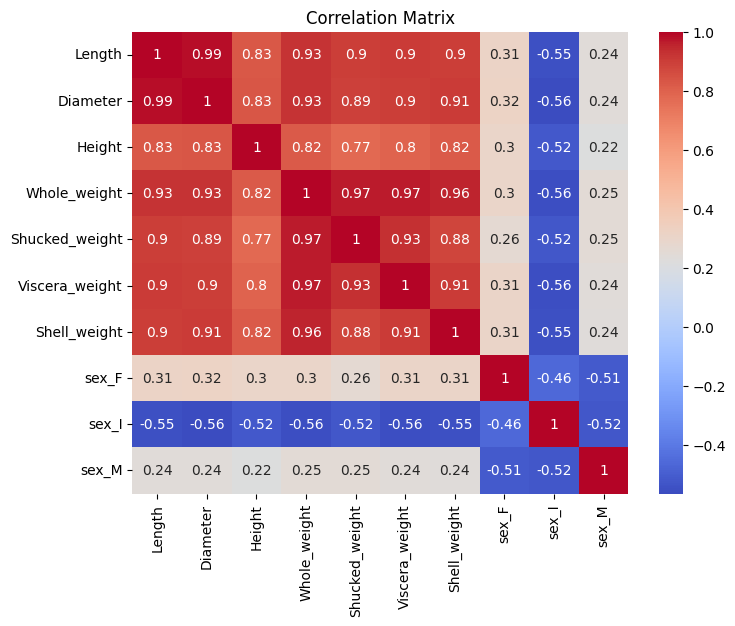

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


corr = df_ohe.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()



In [18]:
df =df_ohe.drop(columns=['Shucked_weight', 'Viscera_weight', 'Shell_weight'])
df2 = df_ohe.drop(columns=['Whole_weight'])
X = df2 

## Scaling and Splitting

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

## Linear Regression

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


def ridge_regression(X_train, X_test, y_train, y_test):

    #X = data.drop(columns=[target_column])
    #y = data[target_column]

    ridge_pipeline = Pipeline([
        ('model', Ridge(alpha=1.0))
    ])

    ridge_pipeline.fit(X_train, y_train)
    y_pred = ridge_pipeline.predict(X_test)

    model = ridge_pipeline.named_steps['model']
    mse = mean_squared_error(y_test, y_pred)

    print("Ridge (pipeline)")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print("R²:", r2_score(y_test, y_pred))
    print("Coefficienti:", model.coef_)
    print("Intercetta:", model.intercept_)

    return ridge_pipeline


def lasso_regression(X_train, X_test, y_train, y_test):

    lasso_pipeline = Pipeline([
        ('model', Lasso(alpha=0.1))
    ])

    lasso_pipeline.fit(X_train, y_train)
    y_pred = lasso_pipeline.predict(X_test)

    model = lasso_pipeline.named_steps['model']
    mse = mean_squared_error(y_test, y_pred)

    print("Lasso (pipeline)")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print("R²:", r2_score(y_test, y_pred))
    print("Coefficienti:", model.coef_)
    print("Intercetta:", model.intercept_)

    return lasso_pipeline

In [43]:
model1 = ridge_regression(X_train, X_test, y_train, y_test)
model2 = lasso_regression(X_train, X_test, y_train, y_test)

Ridge (pipeline)
Mean Squared Error (MSE): 5.1651
R²: 0.5228595693604992
Coefficienti: [  3.24301591   7.21873573   7.98033476 -10.92558965   0.39060795
  18.58140899   0.25920225  -0.58432663   0.32512439]
Intercetta: [3.5808011]
Lasso (pipeline)
Mean Squared Error (MSE): 6.8472
R²: 0.3674744021854117
Coefficienti: [ 0.          0.          0.          0.          0.          6.86067074
  0.         -1.32930224  0.        ]
Intercetta: [8.72796751]


## Neural Network

In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Input
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # forza CPU

import tensorflow as tf
print("GPU visibili:", tf.config.list_physical_devices("GPU"))

# define regression model
def regression_model():
    # create model
    model = Sequential()
    model.add(Input(shape=(9,)))
    model.add(Dense(50, activation='relu'))
    model.add(Dense(50, activation='relu'))
    model.add(Dense(1))
    
    # compile model
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model


#NN  -> MSE: 4.928940, R2: 0.544680
#LR  -> MSE: 5.156948, R2: 0.523617

#NN  -> MSE: 4.767396, R2: 0.559602
#LR  -> MSE: 5.156948, R2: 0.523617

#NN  -> MSE: 4.748704, R2: 0.561329
#LR  -> MSE: 5.156948, R2: 0.523617

GPU visibili: []


In [47]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Input
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # forza CPU

import tensorflow as tf
print("GPU visibili:", tf.config.list_physical_devices("GPU"))

# define regression model
def regression_model():
    # create model
    model = Sequential()
    model.add(Input(shape=(9,)))
    model.add(Dense(50, activation='relu'))
    model.add(Dense(50, activation='relu'))
    model.add(Dense(50, activation='relu'))
    model.add(Dense(1))
    
    # compile model
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

GPU visibili: []


In [52]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Input
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # forza CPU

import tensorflow as tf
print("GPU visibili:", tf.config.list_physical_devices("GPU"))

# define regression model
def regression_model():
    # create model
    model = Sequential()
    model.add(Input(shape=(9,)))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))
    
    # compile model
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

GPU visibili: []


In [53]:
# build the model
model = regression_model()


In [50]:
from sklearn.preprocessing import StandardScaler
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    min_delta=1e-4,
    restore_best_weights=True
)

history = model.fit(
    X_scaled, y,
    validation_split=0.3,
    epochs=1000,
    verbose=2,
    callbacks=[early_stop]
)
min_val_loss = np.min(history.history["val_loss"])

print("Min val_loss:", min_val_loss)

Epoch 1/1000
92/92 - 1s - 16ms/step - loss: 4.8771 - val_loss: 4.2639
Epoch 2/1000
92/92 - 1s - 15ms/step - loss: 4.9818 - val_loss: 4.2040
Epoch 3/1000


KeyboardInterrupt: 

In [54]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    min_delta=1e-4,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.3,
    epochs=1000,
    verbose=2,
    callbacks=[early_stop]
)
min_val_loss = np.min(history.history["val_loss"])

print("Min val_loss:", min_val_loss)

# 2) fit rete (NOTA: non usare validation_split qui se vuoi usare X_test come test)
# se vuoi comunque usare validation durante training, tieni validation_split ma X_test rimane fuori dal training
#model.fit(X_scaled, y_train, validation_split=0.1, epochs=100, verbose=2)

# 3) predizioni della rete sul test set
y_pred_nn = model.predict(X_test).ravel()

# 4) fit regressione lineare (esempio con scikit-learn) sui medesimi X_train/y_train
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test).ravel()

# 5) metriche
mse_nn = mean_squared_error(y_test, y_pred_nn)
r2_nn  = r2_score(y_test, y_pred_nn)

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr  = r2_score(y_test, y_pred_lr)

print(f"NN  -> MSE: {mse_nn:.6f}, R2: {r2_nn:.6f}")
print(f"LR  -> MSE: {mse_lr:.6f}, R2: {r2_lr:.6f}")

Epoch 1/1000
74/74 - 5s - 65ms/step - loss: 73.0342 - val_loss: 9.9602
Epoch 2/1000
74/74 - 1s - 13ms/step - loss: 8.0740 - val_loss: 6.7045
Epoch 3/1000
74/74 - 1s - 11ms/step - loss: 7.2574 - val_loss: 6.5371
Epoch 4/1000
74/74 - 1s - 11ms/step - loss: 7.0454 - val_loss: 6.3166
Epoch 5/1000
74/74 - 1s - 11ms/step - loss: 6.8286 - val_loss: 5.9762
Epoch 6/1000
74/74 - 1s - 9ms/step - loss: 6.6121 - val_loss: 5.7198
Epoch 7/1000
74/74 - 1s - 10ms/step - loss: 6.4288 - val_loss: 5.7120
Epoch 8/1000
74/74 - 1s - 10ms/step - loss: 6.1893 - val_loss: 5.3142
Epoch 9/1000
74/74 - 1s - 10ms/step - loss: 6.0086 - val_loss: 5.2195
Epoch 10/1000
74/74 - 1s - 13ms/step - loss: 5.8374 - val_loss: 4.9390
Epoch 11/1000
74/74 - 1s - 11ms/step - loss: 5.6477 - val_loss: 4.7036
Epoch 12/1000
74/74 - 1s - 9ms/step - loss: 5.5056 - val_loss: 4.6148
Epoch 13/1000
74/74 - 1s - 11ms/step - loss: 5.3920 - val_loss: 4.5146
Epoch 14/1000
74/74 - 1s - 11ms/step - loss: 5.2892 - val_loss: 4.4365
Epoch 15/1000
74